# day 13 | 250926 F

Let's integrate data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/velocities.txt', sep='\t', names=['t', 'v'])
df

,t,v
0,0,0.000000
1,1,0.069478
2,2,0.137694
3,3,0.204332
4,4,0.269083
...,...,...
96,96,0.223073
97,97,0.254244
98,98,0.283753
99,99,0.311479


In [52]:
def trap(x_data, y_data):
    if type(x_data)==pd.core.series.Series:
        x_data = np.asarray(x_data)
        y_data = np.asarray(y_data)
    dx = (x_data[-1]-x_data[0])/len(x_data)
    s = dx/2*(y_data[0]+y_data[-1])
    s = s + np.sum(y_data[1:-2]*dx)
    return(s)

def simp(func, a, b, steps):
    if steps%2!=0:
        steps = steps + 1
        print('i added one step')
    dx = (b-a)/steps
    x = np.linspace(a, b, steps+1)
    y = func(x)
    s = dx/3*(func(a)+func(b))
    s = s + dx/3*(4*np.sum(y[1:steps:2]) + 2*np.sum(y[2:steps-1:2]))
    return(s)

In [53]:
x = np.linspace(0,2, 10000)
y = x**4 - 2*x + 1

In [54]:
trap(x, y)

4.396961306605322

In [55]:
trap(df['t'], df['v'])

7.8291534653465344

In [56]:
integrals = [0]


for i in range(1,101):
    w = trap(df['t'][0:i], df['v'][0:i])
    integrals.append(w)

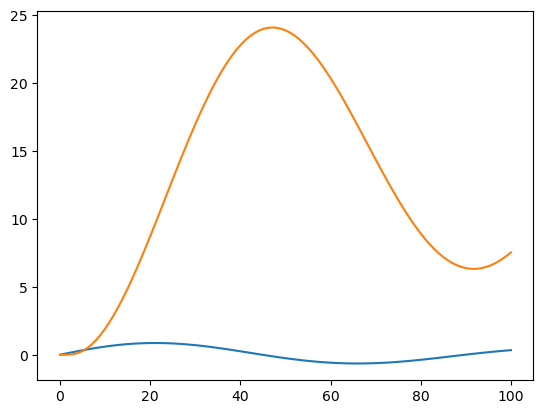

In [57]:
fig, ax = plt.subplots()
ax.plot(df['t'], df['v'])
ax.plot(df['t'], integrals)

In [58]:
integrals[-1]

7.534669724999998

In [63]:
df['t'].values[-1]

100

In [29]:
df['t'].index

RangeIndex(start=0, stop=101, step=1)

In [33]:
range(1,10)

range(1, 10)

In [1]:
def integrate(x, y):
    '''simpson's rule for integration with simpson’s 3/8 rule adjustment for even-length data'''

    if isinstance(x, pd.Series):
        x = x.to_numpy()
        y = y.to_numpy()

    steps = len(y)

    h = (x[-1] - x[0]) / (steps - 1)  # step size (ensuring correct intervals)

    if steps % 2 == 1:  # odd number of points -> use standard Simpson's 1/3 rule
        s = (h / 3) * (y[0] + y[-1] + 4 * np.sum(y[1:steps-1:2]) + 2 * np.sum(y[2:steps-2:2]))

    else:  # even number of points -> use Simpson’s 1/3 rule for first n-3 and 3/8 rule for last three
        s_simpson = (h / 3) * (y[0] + y[-3] + 4 * np.sum(y[1:steps-3:2]) + 2 * np.sum(y[2:steps-4:2]))
        s_three_eighth = (3 * h / 8) * (y[-3] + 3 * y[-2] + 3 * y[-1] + y[-1])  # last 3 points
        s = s_simpson + s_three_eighth

    return s
